# Sampling from arbitrary distributions


(array([0.01875012, 0.07593799, 0.21187633, 0.29343926, 0.30937702,
        0.36000215, 0.37593996, 0.34500226, 0.45375297, 0.44343991,
        0.52312842, 0.57000373, 0.52219092, 0.57750313, 0.56437869,
        0.52594094, 0.51656588, 0.35531482, 0.36093946, 0.33656433,
        0.26812705, 0.22406372, 0.195939  , 0.15375083, 0.1471883 ,
        0.12281344, 0.09750053, 0.07406307, 0.06281284, 0.05906282,
        0.04218782, 0.02343763, 0.02062511, 0.03000023, 0.02625014,
        0.00843756, 0.02156267, 0.01125006, 0.0187501 , 0.00750004,
        0.00093751, 0.00468753, 0.00187502, 0.00468753, 0.00093751,
        0.00187501, 0.00375002, 0.        , 0.        , 0.00093751]),
 array([0.0802    , 0.186866  , 0.29353198, 0.40019798, 0.50686401,
        0.61352998, 0.72019601, 0.82686198, 0.93352795, 1.04019392,
        1.14686   , 1.25352597, 1.36019194, 1.46685791, 1.573524  ,
        1.68018997, 1.78685594, 1.8935219 , 2.00018787, 2.10685396,
        2.21352005, 2.3201859 , 2.42685199, 2.

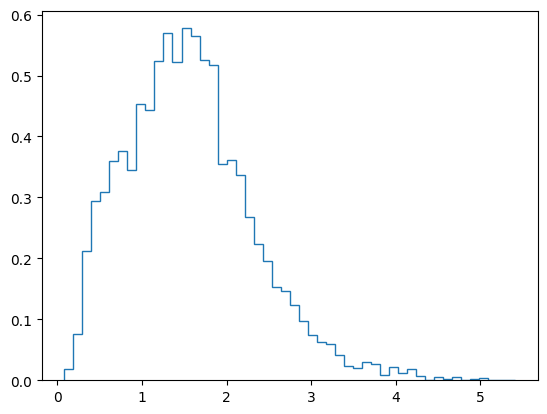

In [18]:
import numpy as np 
import matplotlib.pyplot as plt 
import random
from random import sample
import scipy.stats

from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']
plt.hist(z,bins=50,histtype='step',density=True)


## Rejection sampling 

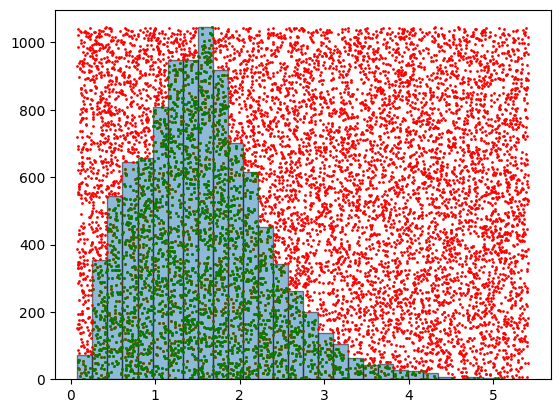

In [116]:
a,b,c=plt.hist(z, bins=30, edgecolor='black', alpha=0.5) #a are the counts
np.histogram(z, bins=30)

x=np.random.uniform(np.min(z), np.max(z), 10000)            #random distribution from 0 to 5 
u=np.random.uniform(0, np.max(a), 10000)                    # a is needed to find the maximum

plt.scatter(x,u, color='red', s=1)

#b are the bin edges
index=np.searchsorted(b,x)-1                        #where x would be inserted in b

values_accepted= u <= a[index]

x_i=x[values_accepted]
u_i=u[values_accepted]

plt.scatter(x_i,u_i, color='green', s=1)

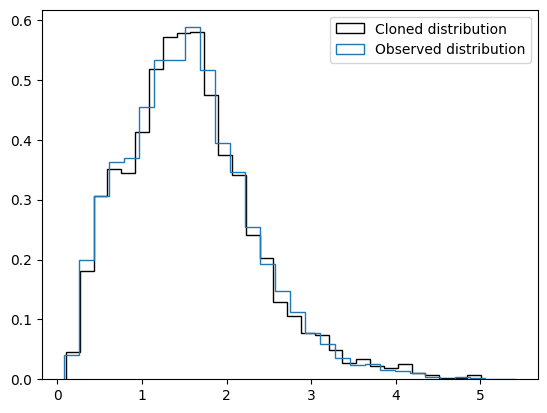

In [16]:
plt.hist(x_i, bins=30, edgecolor='black', color='green', density=True, histtype='step', label='Cloned distribution')
plt.hist(z, bins=30, density=True, histtype='step', label='Observed distribution' )
plt.legend()
plt.show()

## Rejection sampling 2

Less discarded points


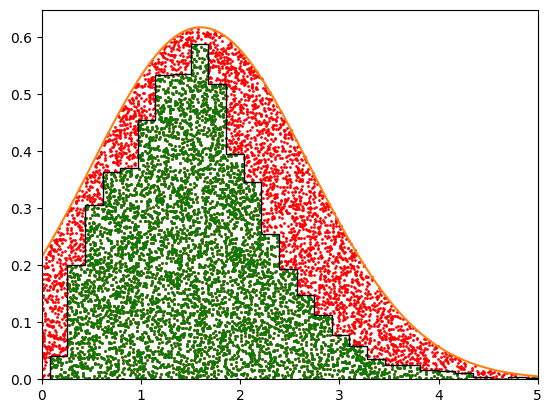

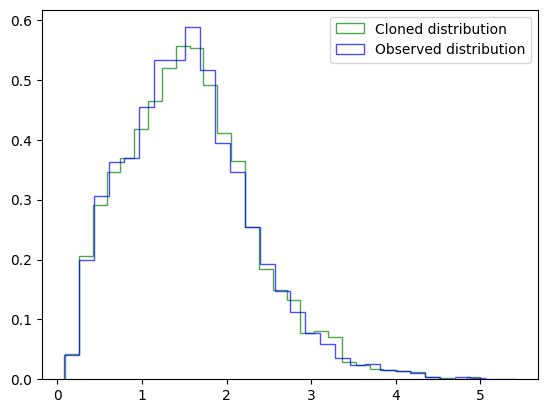

In [119]:
au,bu,c=plt.hist(z, bins=30, edgecolor='black', density=True, histtype='step') #a are the counts

gauss = scipy.stats.norm(loc=1.6,scale=1.1)
plt.plot(np.linspace(0,np.max(b),100), 1.7*gauss.pdf(np.linspace(0,np.max(b),100)))

x2=gauss.rvs(size=10000)  

u2=np.random.uniform(0, 1.7*gauss.pdf(x2), 10000)  

plt.scatter(x2,u2, color='red', s=1)
plt.xlim(0,5)

index_g=np.searchsorted(bu,x2)-1 #where x would be inserted in b

valid = (index_g >= 0) & (index_g < len(au))

values_inside_g = np.zeros_like(u2, dtype=bool)
values_inside_g[valid] = u2[valid] <= au[index_g[valid]]


g_i=x2[values_inside_g]
ug_i=u2[values_inside_g]

plt.scatter(g_i,ug_i, color='green', s=1)
plt.show()
plt.hist(g_i, bins=30, histtype='step', color='green', density=True, alpha=0.7, label='Cloned distribution')
plt.hist(z, bins=30, histtype='step', color='blue', density=True, alpha=0.7, label='Observed distribution' )
plt.legend()
plt.show()


## Inverse transform sampling 

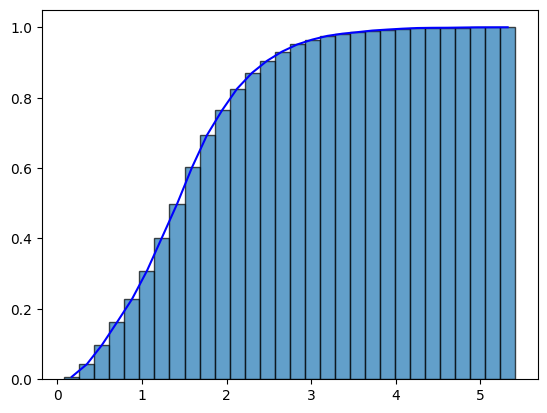

In [ ]:

plt.hist(z,30, edgecolor='black', cumulative=True, alpha=0.7, density=True) # a values of cumulative 
bin_mids = (b[1:] + b[:-1]) / 2 # mid location of bins

simple_cdf = np.cumsum(a) / np.sum(a)           # this is the cumulative, by points

plt.plot(bin_mids, simple_cdf, label='Cumulative distribution', color='blue')


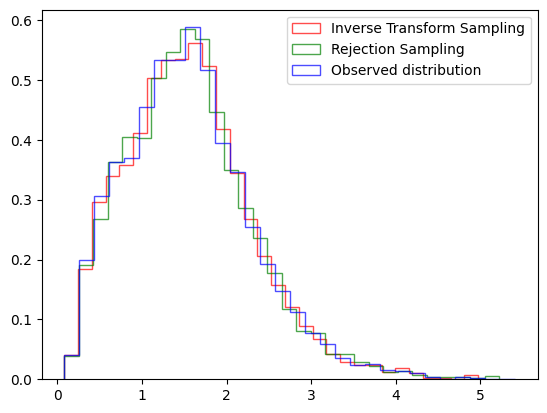

In [140]:
y=np.random.uniform(0,1,10000)

index=np.searchsorted(simple_cdf,y) #where y would be inserted in a

w=np.random.uniform(b[index], b[index+1])


plt.hist(w, bins=30, histtype='step', color='red', density=True, alpha=0.7, label='Inverse Transform Sampling')
plt.hist(x_i, bins=30, histtype='step', color='green', density=True, alpha=0.7, label='Rejection Sampling')
plt.hist(z, bins=30, histtype='step' , color='blue', density=True, alpha=0.7, label='Observed distribution' )
plt.legend()

plt.show()


